# Exploratory Data Analysis

This notebook conducts EDA on the pre-processed Archelec corpus.

# Set Up the Environment

In [32]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import math
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np



# Define paths relative to this notebook's location 
current_dir = Path.cwd()
project_root = current_dir.parent
meta_dir = project_root / "metadata"
data_dir = project_root / "data"

In [33]:
master_df = pd.read_parquet(data_dir / 'cleaned_master_data.parquet')

Verify the data

In [34]:
master_df[['id', 'year', 'text', 'cleaned_text','final_tokens']].sample(5)

,id,year,text,cleaned_text,final_tokens
16573,EL104_L_1978_03_059_02_1_PF_02,1978,Sciences Po / fonds CEVIPOF\nunion ouvrière et...,Sciences Po / fonds CEVIPOF union ouvrière et ...,union ouvrier_paysan démocratie_prolétarien ph...
27098,EL189_L_1993_03_006_07_1_PF_03,1993,Sciences Po / fonds CEVIPOF\nÉLECTIONS LÉGISLA...,Sciences Po / fonds CEVIPOF ÉLECTIONS LÉGISLAT...,républiqu_français èm_circonscription pierre_m...
13264,EL069_L_1973_03_081_03_1_PF_01,1973,UNION POUR LA MAJORITÉ PRÉSIDENTIELLE DE SOUTI...,UNION POUR LA MAJORITÉ PRÉSIDENTIELLE DE SOUTI...,union bernard royer agriculteur marie-christin...
17082,EL105_L_1978_03_069_11_1_PF_10,1978,Sciences Po / fonds CEVIPOF\nSi vous voulez\nc...,Sciences Po / fonds CEVIPOF Si vous voulez cha...,votez_utile tour suffrage maire socialiste st_...
30520,EL196_L_1993_03_076_11_1_PF_05,1993,Elections législatives du 21 mars 1993\nPourqu...,Elections législatives du mars Pourquoi voter ...,lutte_ouvrière appel_arlette laguiller_faveur ...


## Corpus Statistics

In [35]:
# Number of documents
num_docs = len(master_df)
print(f"Number of documents: {num_docs}")

# Average length of raw text 
avg_length = master_df['text'].astype(str).str.split().str.len().mean()
print(f"Average words in raw text: {avg_length:.2f}")

# Average number of tokens
avg_tokens = master_df['final_tokens'].astype(str).str.split().str.len().mean()

# Print the average number of final tokens
print(f"Average number of final tokens: {avg_tokens:.2f}")


Number of documents: 21167
Average words in raw text: 711.74
Average number of final tokens: 153.00


## Documents

In [36]:
# Number of documents by gender 
women_count = len(master_df[master_df['titulaire-sexe']=="femme"])
men_count = len(master_df[master_df['titulaire-sexe']=="homme"])
non_determined_count= len(master_df[master_df['titulaire-sexe']=="non déterminé"])
print(f"Number of documents by gender:")
print(f"- Women: {women_count}")
print(f"- Men: {men_count}")
print(f"- Non-determined: {non_determined_count}")

Number of documents by gender:
- Women: 2160
- Men: 18171
- Non-determined: 836



Number of documents by year and gender:
titulaire-sexe  femme  homme  non déterminé
year                                       
1973              195   3573             75
1978              659   4135             33
1981              316   2799              6
1988              347   3108             84
1993              643   4556            638


<Figure size 1200x600 with 0 Axes>

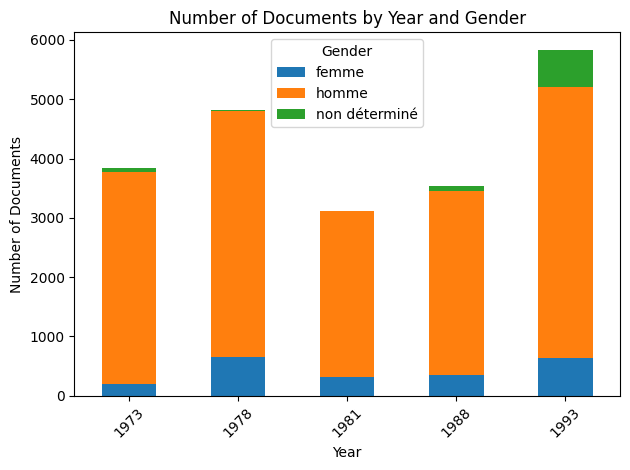

In [37]:
# Count documents by year and gender
year_gender_counts = master_df.groupby(['year', 'titulaire-sexe']).size().unstack(fill_value=0)
print("\nNumber of documents by year and gender:")
print(year_gender_counts)

# Barplot
plt.figure(figsize=(12, 6))
gender_counts = master_df.groupby(['year', 'titulaire-sexe']).size().unstack(fill_value=0)
gender_counts.plot(kind='bar', stacked=True)
plt.title('Number of Documents by Year and Gender')
plt.xlabel('Year')  
plt.ylabel('Number of Documents')
plt.legend(title='Gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() 

# Looking into non-determined gender 

This section investigates the 'non déterminé' gender category and explores whether name could be recovered to potentially assing gender.

In [38]:
# Statistics on 'non détérminé' category
non_determined = master_df[master_df['titulaire-sexe'] == 'non déterminé']
num_non_determined = len(non_determined)
print(f"Number of 'non déterminé' entries: {num_non_determined}")

# Count by year
non_determined_by_year = non_determined['year'].value_counts().sort_index()
print("Number of 'non déterminé' entries by year:")
print(non_determined_by_year)

# Count unavailable names for 'non déterminé' entries n
unavailable_names = (non_determined['titulaire-nom'] == "non mentionné").sum() 
print(f"Number of 'non déterminé' entries with unavailable names: {unavailable_names}")

# Count by 'titulaire-soutien'
non_determined_by_soutien = non_determined['titulaire-soutien'].value_counts()
print("Number of 'non déterminé' entries by 'titulaire-soutien':")
print(non_determined_by_soutien)


# Most frequent tokens
all_tokens = non_determined['final_tokens'].dropna().str.split().explode()
token_counts = Counter(all_tokens)
most_common_tokens = token_counts.most_common(20)
print("Most common tokens in 'non déterminé' entries:")
for token, count in most_common_tokens:
    print(f"{token}: {count}") 


Number of 'non déterminé' entries: 836
Number of 'non déterminé' entries by year:
year
1973     75
1978     33
1981      6
1988     84
1993    638
Name: count, dtype: int64
Number of 'non déterminé' entries with unavailable names: 815
Number of 'non déterminé' entries by 'titulaire-soutien':
titulaire-soutien
Nouveaux écologistes du rassemblement nature et animaux                                                                                         342
Lutte ouvrière                                                                                                                                  194
Parti ouvrier européen                                                                                                                           77
Ligue communiste                                                                                                                                 66
Nouveaux écologistes du rassemblement nature et animaux;Union nationale écologiste;Parti pour la 

In [39]:
# Count by titulaire-soutien and year
non_determined_soutien_year = non_determined.groupby(['year', 'titulaire-soutien']).size().unstack(fill_value=0)
print("Number of 'non déterminé' entries by year and 'titulaire-soutien':")
non_determined_soutien_year

Number of 'non déterminé' entries by year and 'titulaire-soutien':


titulaire-soutien,Alliance européenne des travailleurs,Amis de la Terre,Chrétiens pour un monde nouveau,Comité anti-pollution;Groupe non-violent Louis-Lecoin,Comités communistes autogestionnaires,Comités communistes autogestionnaires;Ligue communiste révolutionnaire;Organisation communiste des travailleurs,Comités communistes pour l'autogestion;Organisation des communistes travailleurs;Ligue communiste révolutionnaire,Front national,Front national;Association de défense de la famille en Yvelines,Ligue communiste,...,Parti des travailleurs,Parti des travailleurs;Alliance européenne des travailleurs,Parti des travailleurs;Alliance européenne des travailleurs;Entente internationale des travailleurs,Parti ouvrier européen,Parti socialiste démocrate,Parti socialiste unifié,Rassemblement pour la République;Union pour la démocratie française,Union des gaullistes de progrès,Vosges écologie,non mentionné
year,,,,,,,,,,,,,,,,,,,,,
1973,0,0,0,0,0,0,0,0,0,66,...,0,0,0,0,0,0,0,0,0,0
1978,0,1,1,1,1,1,1,5,0,0,...,0,0,0,0,1,0,0,1,0,12
1981,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,2,3
1988,0,0,0,0,0,0,0,0,0,0,...,0,0,0,77,0,0,0,0,0,6
1993,1,0,0,0,0,0,0,1,1,0,...,14,12,14,0,0,0,1,0,0,2


- Gender cannot be attributed for most of the 'non-determined' due to unavailable names. 
- Mostly concentrated in the 1993 elections in two parties : écologistes and lutte ouvrière
- In 1993, almost as much as female candidates

In what follows, I remove these observations.

In [40]:
# Filter out 'non déterminé' entries for gender
filtered_df = master_df[master_df['titulaire-sexe'] != 'non déterminé']
print(f"Number of documents after filtering: {len(filtered_df)}")

Number of documents after filtering: 20331


# Corpus Statistics (men and women only)

In [41]:
# Number of documents
num_docs = len(filtered_df)
print(f"Number of documents: {num_docs}")

# Average length of raw text 
avg_length = filtered_df['text'].astype(str).str.split().str.len().mean()
print(f"Average words in raw text: {avg_length:.2f}")

# Average number of tokens
avg_tokens = filtered_df['final_tokens'].astype(str).str.split().str.len().mean()

# Print the average number of final tokens
print(f"Average number of final tokens: {avg_tokens:.2f}")

Number of documents: 20331
Average words in raw text: 710.50
Average number of final tokens: 154.15


## Plot number of documents per year and gender and the share of female candidates

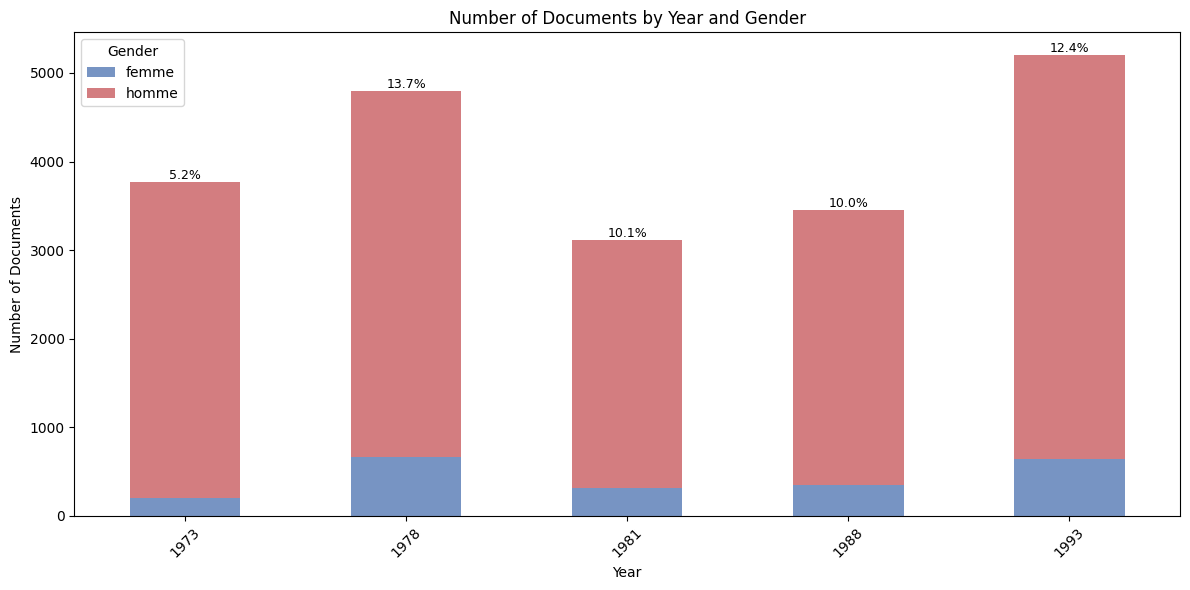

In [42]:
plt.figure(figsize=(12, 6))
gender_counts = filtered_df.groupby(['year', 'titulaire-sexe']).size().unstack(fill_value=0)

colors = ["#4C72B0C2", "#C44E52BB"] 

ax = gender_counts.plot(kind='bar', stacked=True, ax=plt.gca(), color=colors)
plt.title('Number of Documents by Year and Gender')
plt.xlabel('Year')  
plt.ylabel('Number of Documents')
plt.legend(title='Gender')
plt.xticks(rotation=45)

female_label = 'femme' 

# Iterate over the unstacked dataframe to calculate and place the percentages
for i, (year, row) in enumerate(gender_counts.iterrows()):
    total_docs = row.sum()
    
    if total_docs > 0 and female_label in row.index:
        female_count = row[female_label]
        female_share = (female_count / total_docs) * 100
        
        # Add text to the plot: 
        ax.text(i, total_docs, f'{female_share:.1f}%', 
                ha='center', va='bottom', fontsize=9, color='black')


plt.tight_layout()
plt.show() 


# Raw Words - Token by Gender

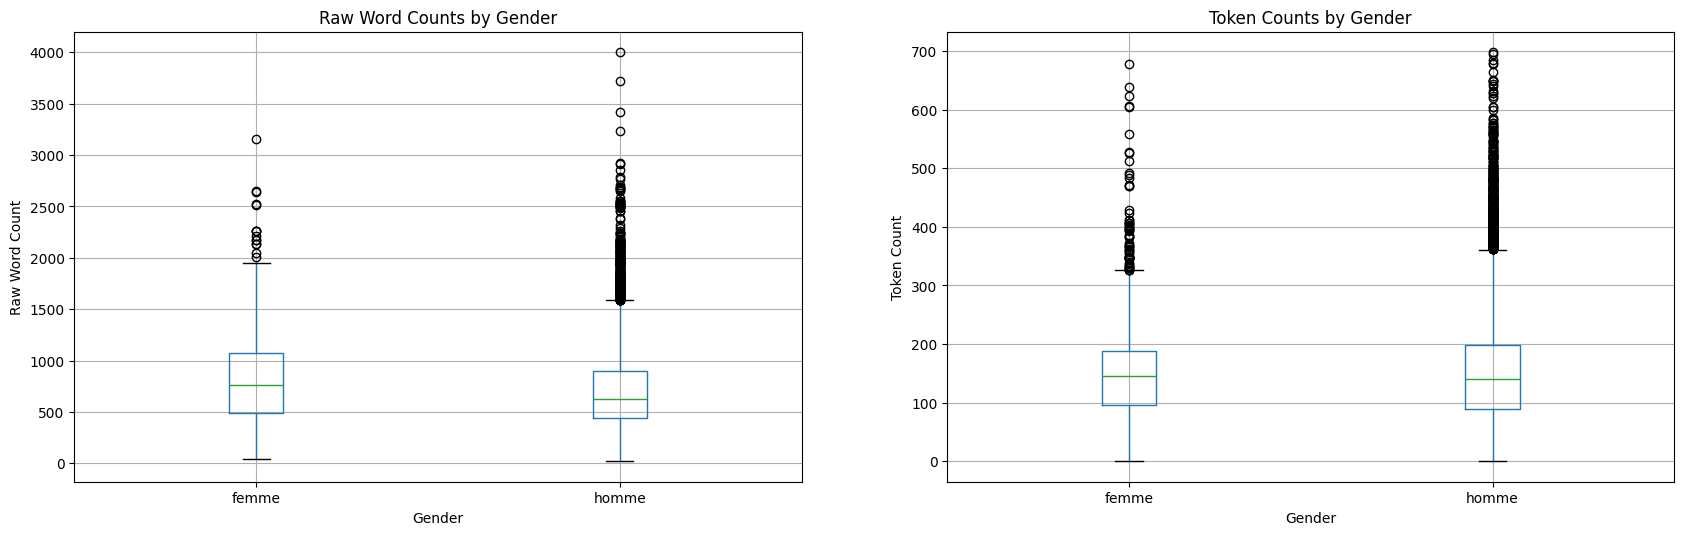

In [43]:
# Plot distribution of raw text lengths and number of tokens by gender
filtered_df['text_length'] = filtered_df['text'].astype(str).str.split().str.len() # Number of words
filtered_df['token_count'] = filtered_df['final_tokens'].astype(str).str.split().str.len() # Number of tokens

# Plot side-by-side boxplots 
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# 1. Boxplot of raw text lengths 
filtered_df.boxplot(column='text_length', by='titulaire-sexe', ax=axes[0])
axes[0].set_title('Raw Word Counts by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Raw Word Count')           

# 2. Boxplot of token counts 
filtered_df.boxplot(column='token_count', by='titulaire-sexe', ax=axes[1])
axes[1].set_title('Token Counts by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Token Count')       

fig.suptitle('')
plt.show()


Manually verify key statistics.

In [44]:
print(filtered_df['text_length'].describe() )
print(filtered_df['token_count'].describe()  )

count    20331.000000
mean       710.498401
std        361.542656
min         19.000000
25%        445.000000
50%        638.000000
75%        912.000000
max       4002.000000
Name: text_length, dtype: float64
count    20331.000000
mean       154.145738
std         85.383302
min          0.000000
25%         90.000000
50%        142.000000
75%        197.000000
max        698.000000
Name: token_count, dtype: float64


Manually verify key statistics by gender

In [45]:
print(filtered_df['text_length'].groupby(filtered_df['titulaire-sexe']).describe() ) 
print(filtered_df['token_count'].groupby(filtered_df['titulaire-sexe']).describe()  )

                  count        mean         std   min     25%    50%      75%  \
titulaire-sexe                                                                  
femme            2160.0  788.886111  379.509834  43.0  487.75  761.0  1076.25   
homme           18171.0  701.180397  358.219103  19.0  440.00  627.0   900.00   

                   max  
titulaire-sexe          
femme           3158.0  
homme           4002.0  
                  count        mean        std  min   25%    50%     75%  \
titulaire-sexe                                                             
femme            2160.0  154.500926  78.844774  0.0  96.0  146.0  188.25   
homme           18171.0  154.103517  86.129468  0.0  89.0  140.0  198.00   

                  max  
titulaire-sexe         
femme           678.0  
homme           698.0  


# Raw Words - Token by Year

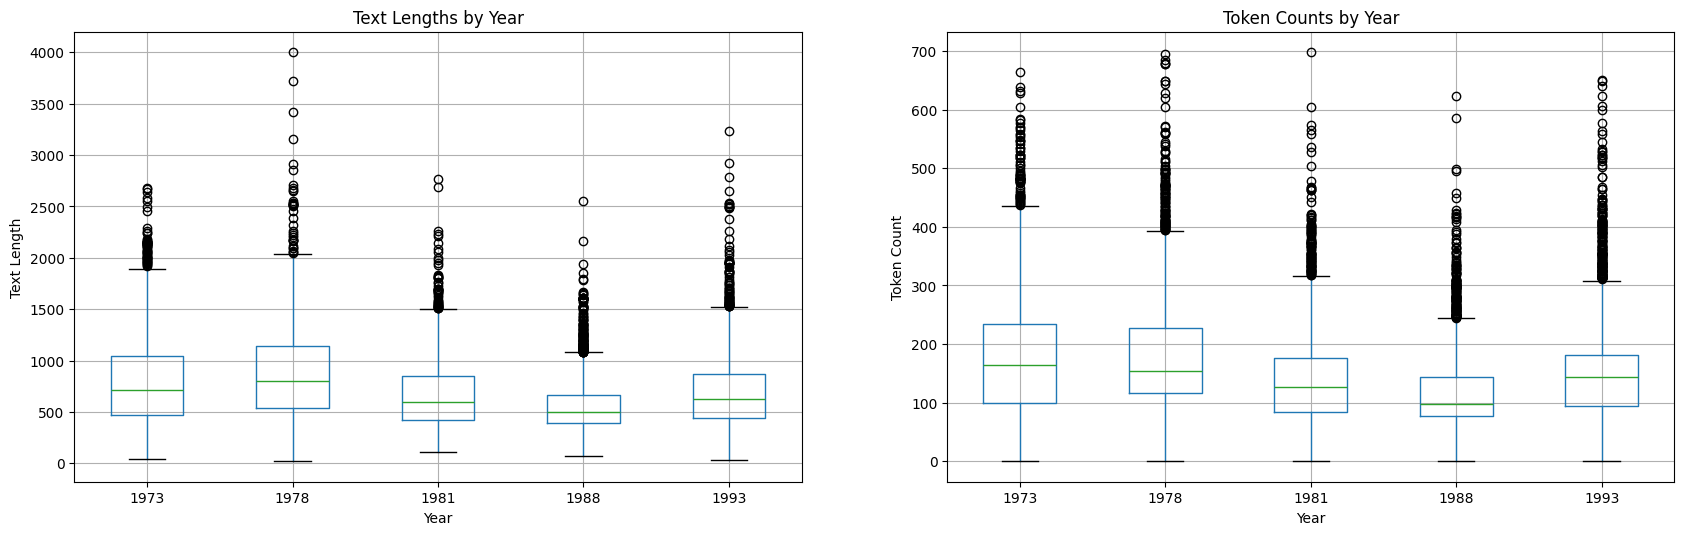

In [46]:
# Plot side-by-side boxplots 
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# 1. Boxplot of raw text lengths 
filtered_df.boxplot(column='text_length', by='year', ax=axes[0])
axes[0].set_title('Text Lengths by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Text Length')           

# 2. Boxplot of token counts
filtered_df.boxplot(column='token_count', by='year', ax=axes[1])
axes[1].set_title('Token Counts by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Token Count')       

fig.suptitle('')
plt.show()

# Raw Words - Token by Gender and Year

Text(0, 0.5, 'Token Count')

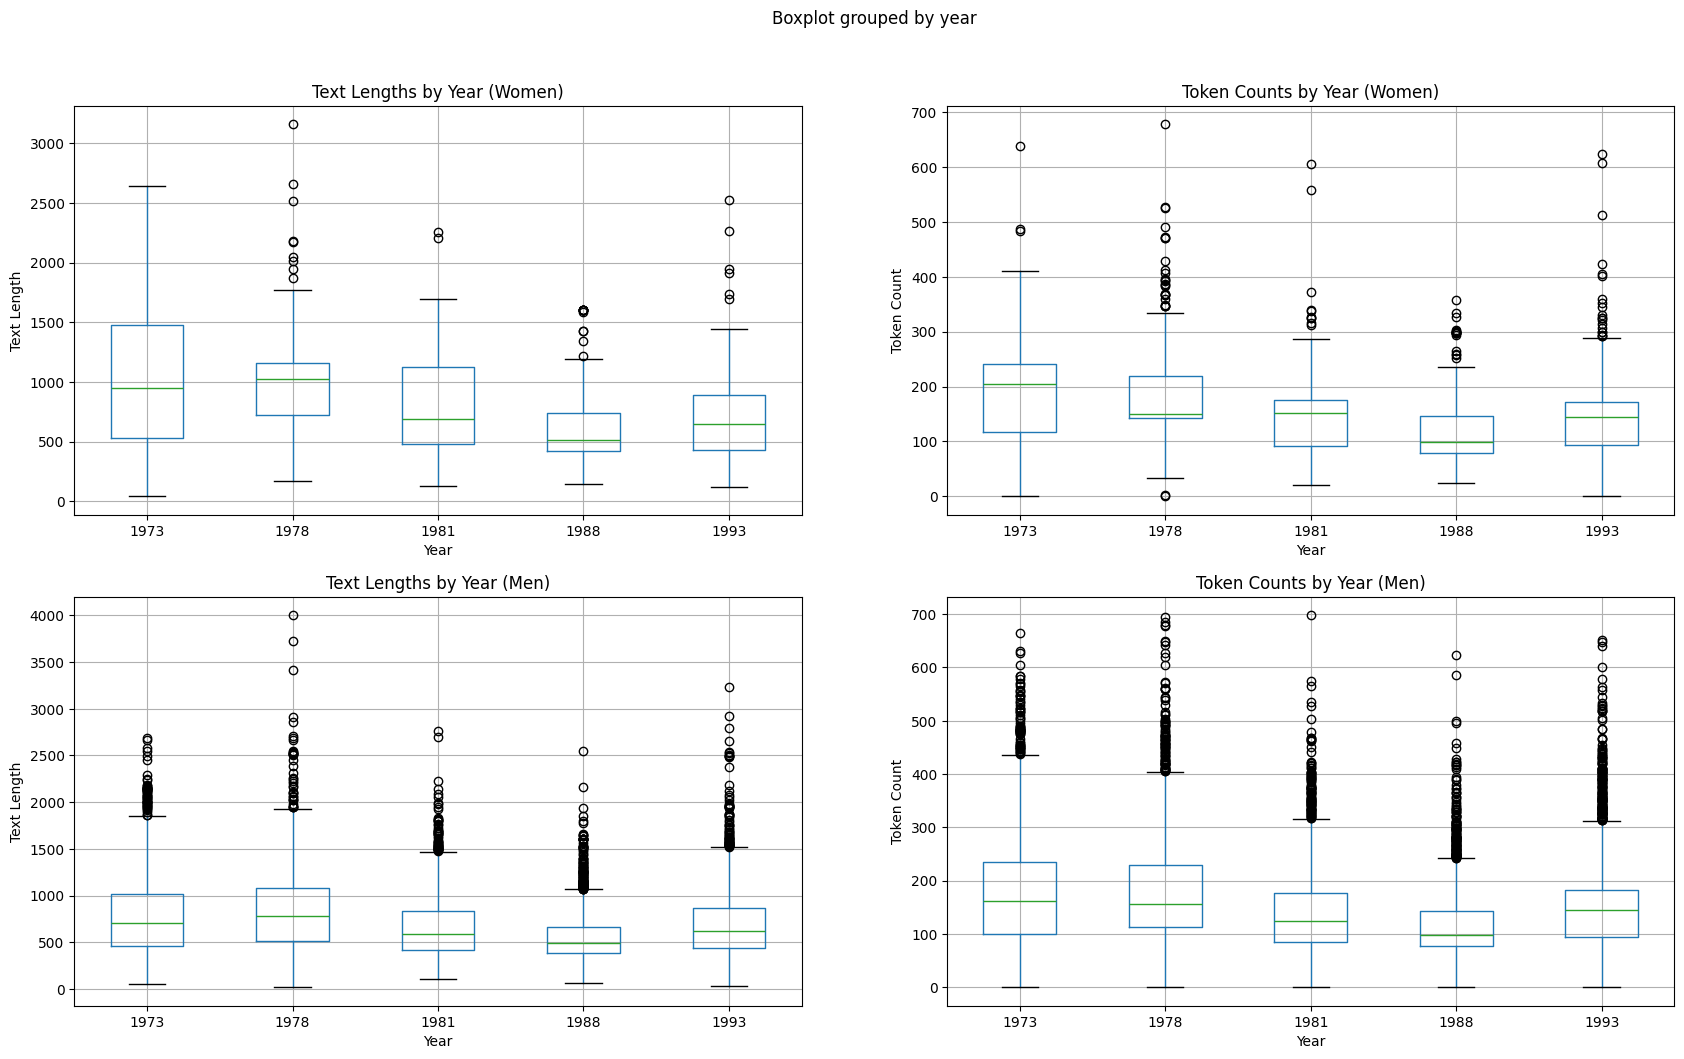

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
# 1. Boxplot for women
filtered_df[filtered_df['titulaire-sexe'] == 'femme'].boxplot(column='text_length', by='year', ax=axes[0, 0])
axes[0, 0].set_title('Text Lengths by Year (Women)')
axes[0, 0].set_xlabel('Year')   
axes[0, 0].set_ylabel('Text Length')
filtered_df[filtered_df['titulaire-sexe'] == 'femme'].boxplot(column='token_count', by='year', ax=axes[0, 1])
axes[0, 1].set_title('Token Counts by Year (Women)')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Token Count')
# 2. Boxplot for men
filtered_df[filtered_df['titulaire-sexe'] == 'homme'].boxplot(column='text_length', by='year', ax=axes[1, 0])
axes[1, 0].set_title('Text Lengths by Year (Men)')
axes[1, 0].set_xlabel('Year')       
axes[1, 0].set_ylabel('Text Length')
filtered_df[filtered_df['titulaire-sexe'] == 'homme'].boxplot(column='token_count', by='year', ax=axes[1, 1])
axes[1, 1].set_title('Token Counts by Year (Men)')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Token Count')


# Top Tokens by Frequency

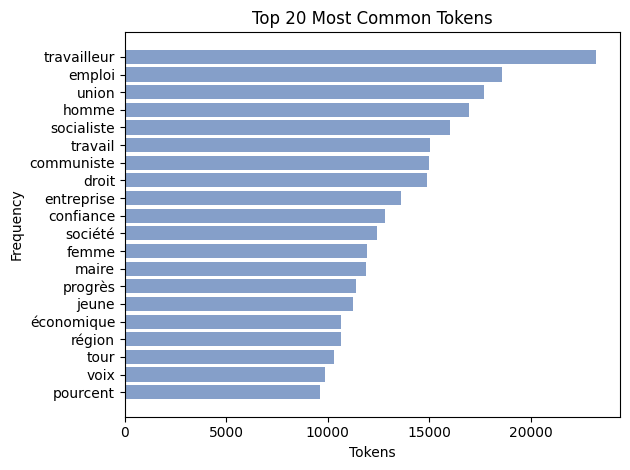

In [48]:
# Top most common tokens plot
all_tokens = filtered_df['final_tokens'].dropna().str.split().explode()
token_counts = Counter(all_tokens)
most_common_tokens = token_counts.most_common(20)
color = ["#4C72B0AD"] 

plt.barh([token for token, count in most_common_tokens], [count for token, count in most_common_tokens], color=color)
plt.title('Top 20 Most Common Tokens')
plt.xlabel('Tokens')
plt.ylabel('Frequency')
plt.gca().invert_yaxis()
plt.xticks()
plt.tight_layout()
plt.show()

## Top Tokens by Gender

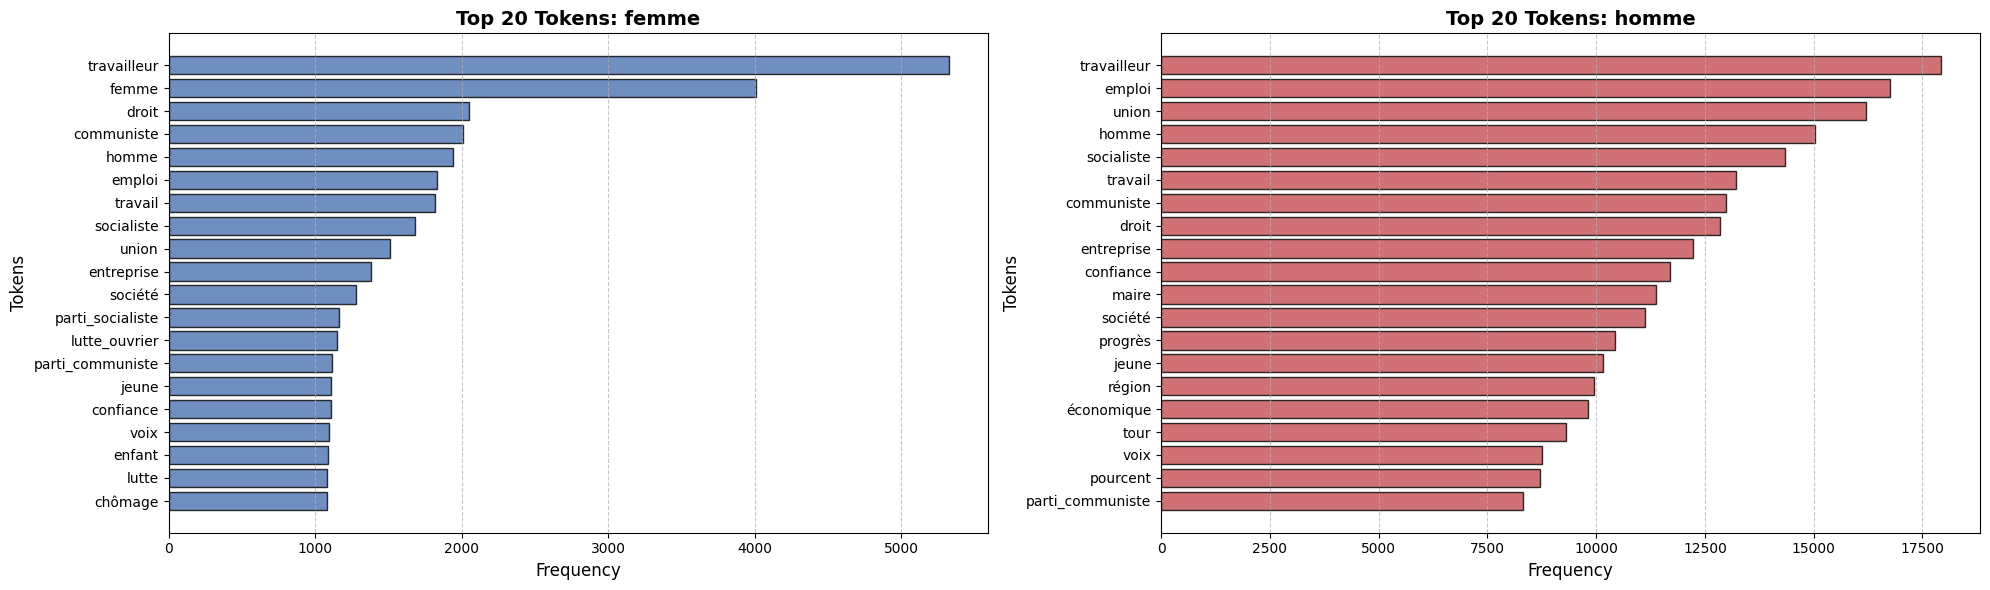

In [49]:
#  Create the figure 
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Colors
colors = ['#4C72B0', '#C44E52'] 

#  Group by gender and iterate 
for i, (gender, group) in enumerate(filtered_df.groupby('titulaire-sexe')):
    
    # Join all tokens for this specific gender
    all_text = " ".join(group['final_tokens'].dropna().astype(str))
    
    # Create the counter and get top 20
    counter = Counter(all_text.split())
    top_tokens = counter.most_common(20)
    
    # Unpack the tokens and counts
    tokens, counts = zip(*top_tokens)
    
    # Assign color based on the current loop index 'i'
    graph_colors = colors[i % len(colors)]
    
    #  Plotting side-by-side for each gender
    ax = axes[i]
    
    ax.barh(tokens, counts, color=graph_colors, edgecolor='black', alpha=0.8)
    
    ax.invert_yaxis()
    ax.set_title(f'Top 20 Tokens: {gender}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Frequency', fontsize=12)
    ax.set_ylabel('Tokens', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

#  Adjust layout and display
plt.tight_layout()
plt.show()

Verify intersection and difference of top tokens

In [50]:
women_tokens = filtered_df[filtered_df['titulaire-sexe'] == 'femme']['final_tokens'].dropna().str.split().explode()
women_token_counts = Counter(women_tokens)
men_tokens = filtered_df[filtered_df['titulaire-sexe'] == 'homme']['final_tokens'].dropna().str.split().explode()
men_token_counts = Counter(men_tokens)
# Get shared tokens among top 20 for each gender
top_women_tokens = set([token for token, count in women_token_counts.most_common(20)])
top_men_tokens = set([token for token, count in men_token_counts.most_common(20)])
shared_tokens = top_women_tokens.intersection(top_men_tokens)
print("Shared   tokens among top 20 for each gender:")
print(shared_tokens)
print(f"Number of shared tokens: {len(shared_tokens)}")

Shared   tokens among top 20 for each gender:
{'voix', 'union', 'parti_communiste', 'confiance', 'jeune', 'société', 'emploi', 'homme', 'communiste', 'travailleur', 'droit', 'entreprise', 'socialiste', 'travail'}
Number of shared tokens: 14


In [51]:
# Verify different tokens
women_unique_tokens = top_women_tokens.difference(top_men_tokens)
men_unique_tokens = top_men_tokens.difference(top_women_tokens)
print("Unique tokens for women:")
print(women_unique_tokens)
print("Unique       tokens for men:")
print(men_unique_tokens)

Unique tokens for women:
{'chômage', 'lutte', 'femme', 'lutte_ouvrier', 'parti_socialiste', 'enfant'}
Unique       tokens for men:
{'tour', 'économique', 'maire', 'pourcent', 'région', 'progrès'}


## Top tokens by gender - Relative Frequency

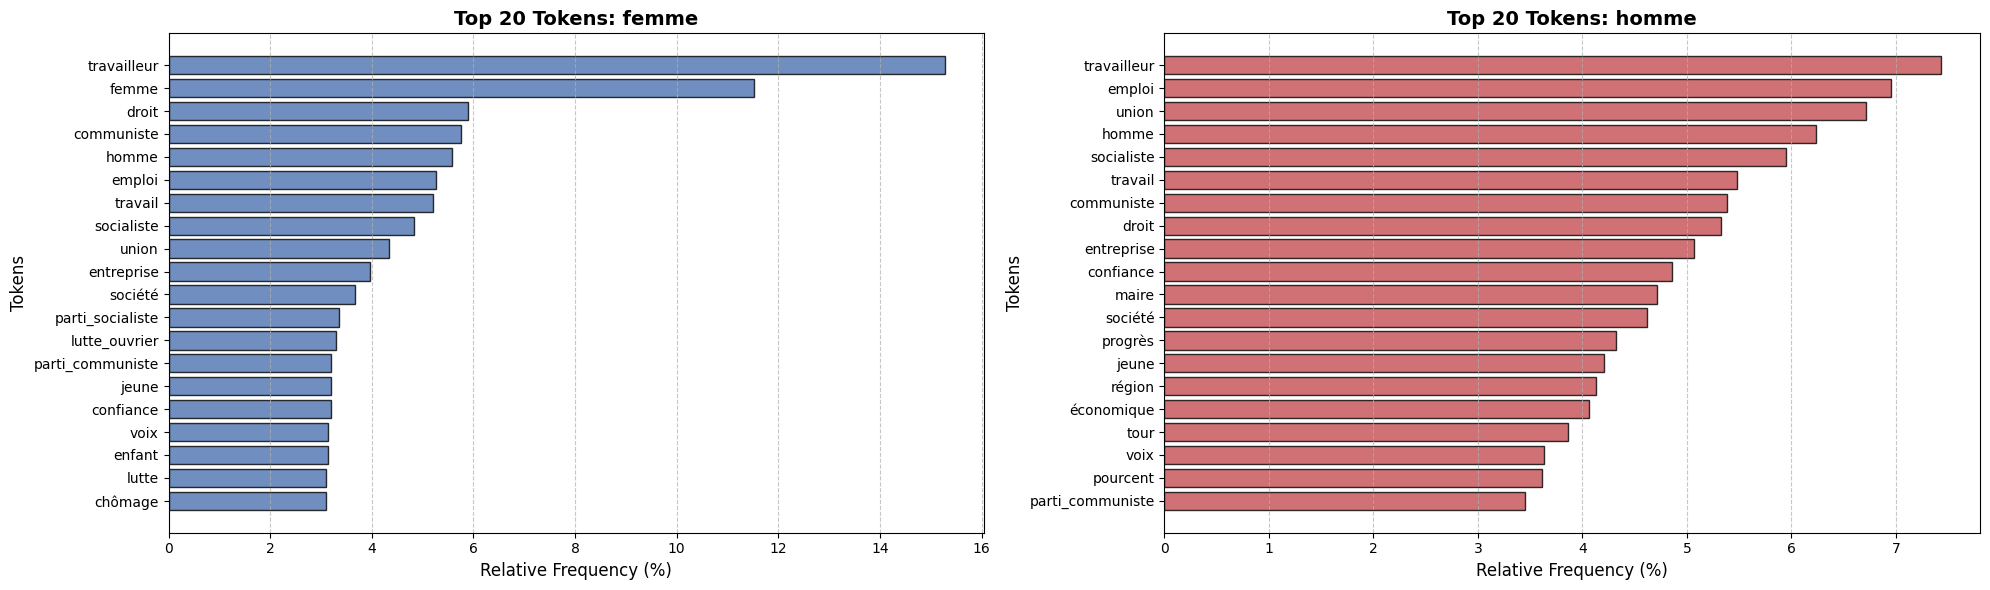

In [52]:
# Create the figure 
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Colors
colors = ['#4C72B0', '#C44E52'] 

# Group by gender and iterate 
for i, (gender, group) in enumerate(filtered_df.groupby('titulaire-sexe')):
    
    # Join all tokens for this specific gender
    all_text = " ".join(group['final_tokens'].dropna().astype(str))
    
    # Split text into a list of tokens once to optimize performance
    all_tokens = all_text.split()
    total_tokens = len(all_tokens) # Total tokens for this gender
    
    # Create the counter and get top 20
    counter = Counter(all_tokens)
    top_tokens = counter.most_common(20)
    
    # Unpack the tokens and raw counts
    tokens, counts = zip(*top_tokens)
    
    # Convert raw counts to relative frequencies (percentages)
    relative_counts = [(count / sum(counts)) * 100 for count in counts]
    
    # Assign color based on the current loop index 'i'
    graph_colors = colors[i % len(colors)]
    
    # Plotting side-by-side for each gender
    ax = axes[i]
    
    # Plot using relative_counts instead of raw counts
    ax.barh(tokens, relative_counts, color=graph_colors, edgecolor='black', alpha=0.8)
    
    ax.invert_yaxis()
    ax.set_title(f'Top 20 Tokens: {gender}', fontsize=14, fontweight='bold')
    
    # Update the x-axis label to indicate percentages
    ax.set_xlabel('Relative Frequency (%)', fontsize=12)
    ax.set_ylabel('Tokens', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout()
plt.show()

## Top Tokens by Gender and Year

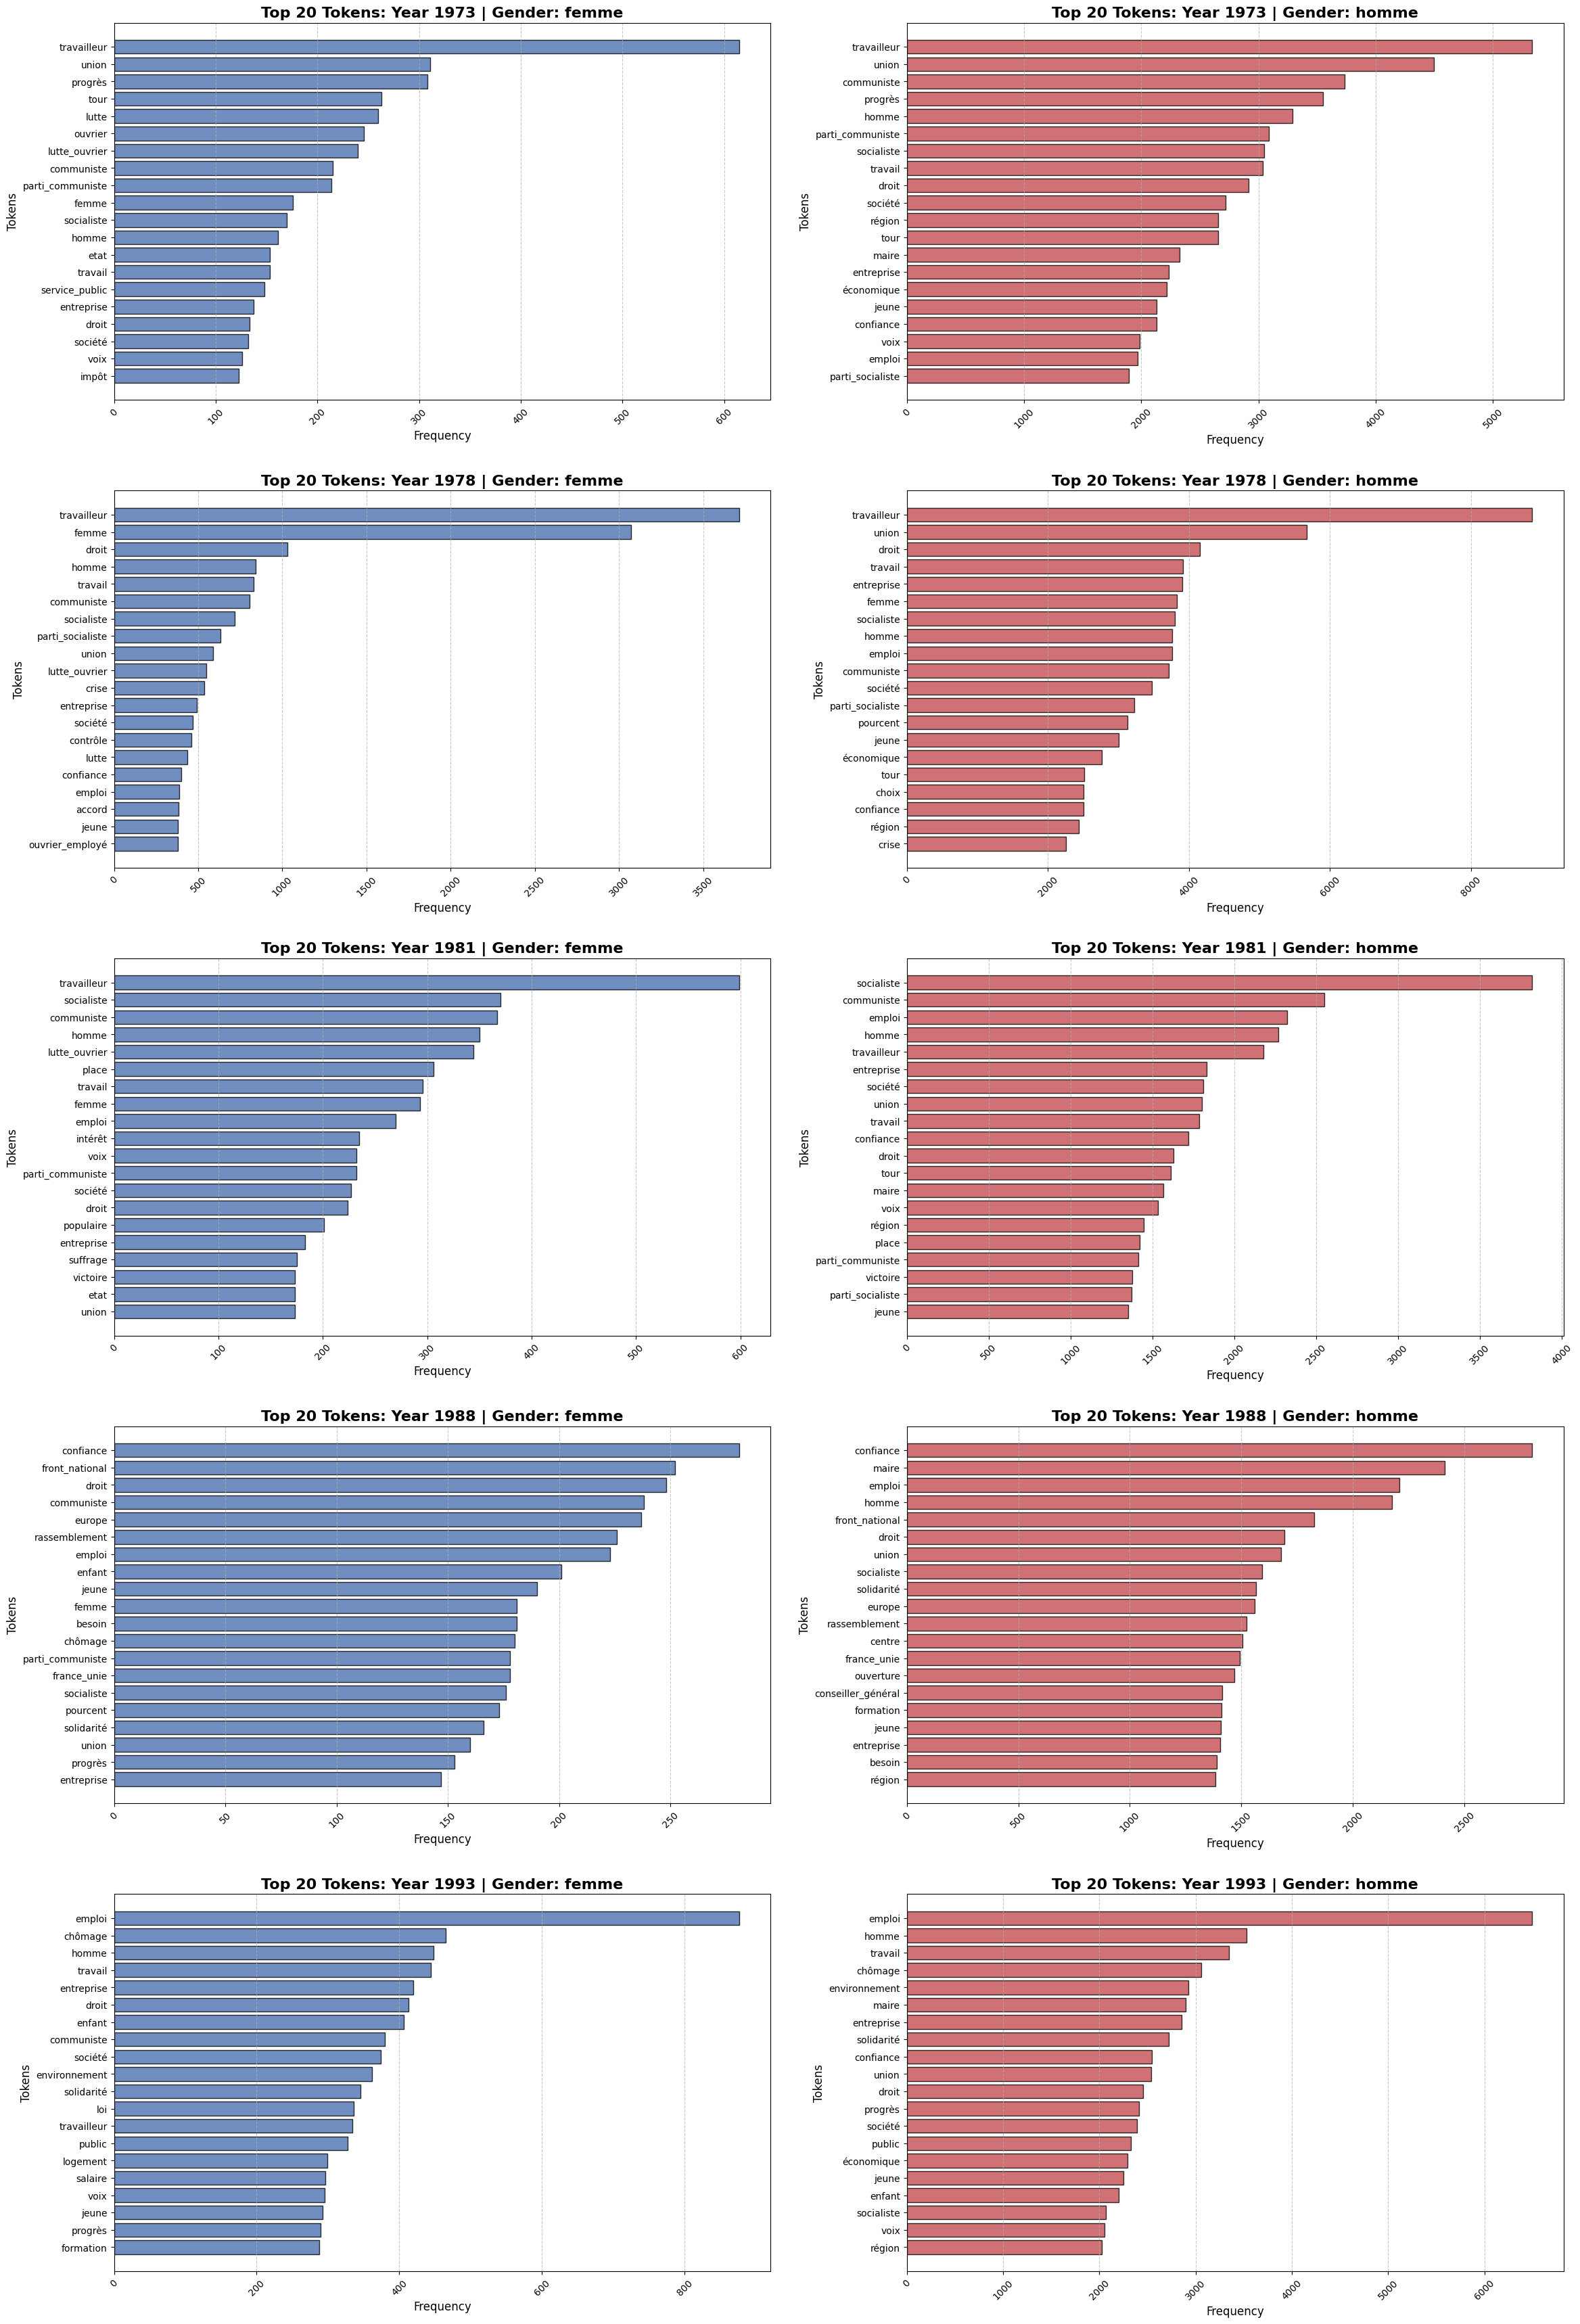

In [53]:
years = sorted(filtered_df['year'].dropna().unique())
genders = sorted(filtered_df['titulaire-sexe'].dropna().unique())

num_years = len(years)
num_genders = len(genders)

# Create plot with a grid 
fig, axes = plt.subplots(nrows=num_years, ncols=num_genders, 
                         figsize=(12 * num_genders, 7 * num_years), 
                         squeeze=False)

# Colors
colors = ['#4C72B0', '#C44E52'] 

#Iterate over the grid
for row_idx, year in enumerate(years):
    for col_idx, gender in enumerate(genders):
        
        ax = axes[row_idx, col_idx]
        
        subset = filtered_df[(filtered_df['year'] == year) & 
                             (filtered_df['titulaire-sexe'] == gender)]
        
        all_text = " ".join(subset['final_tokens'].dropna().astype(str))
        
        counter = Counter(all_text.split())
        top_tokens = counter.most_common(20)
        
        tokens, counts = zip(*top_tokens)
        
        graph_colors = colors[col_idx % len(colors)]
        
        ax.barh(tokens, counts, color=graph_colors, edgecolor='black', alpha=0.8)
        ax.invert_yaxis()
        
        ax.set_title(f'Top 20 Tokens: Year {year} | Gender: {gender}', fontsize=16, fontweight='bold')
        ax.set_xlabel('Frequency', fontsize=12)
        ax.set_ylabel('Tokens', fontsize=12)
        ax.tick_params(axis='x', rotation=45) 
        
        ax.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust and display
plt.tight_layout(pad=3.0)
plt.show()


# Word Clouds

## Word Clouds by Year

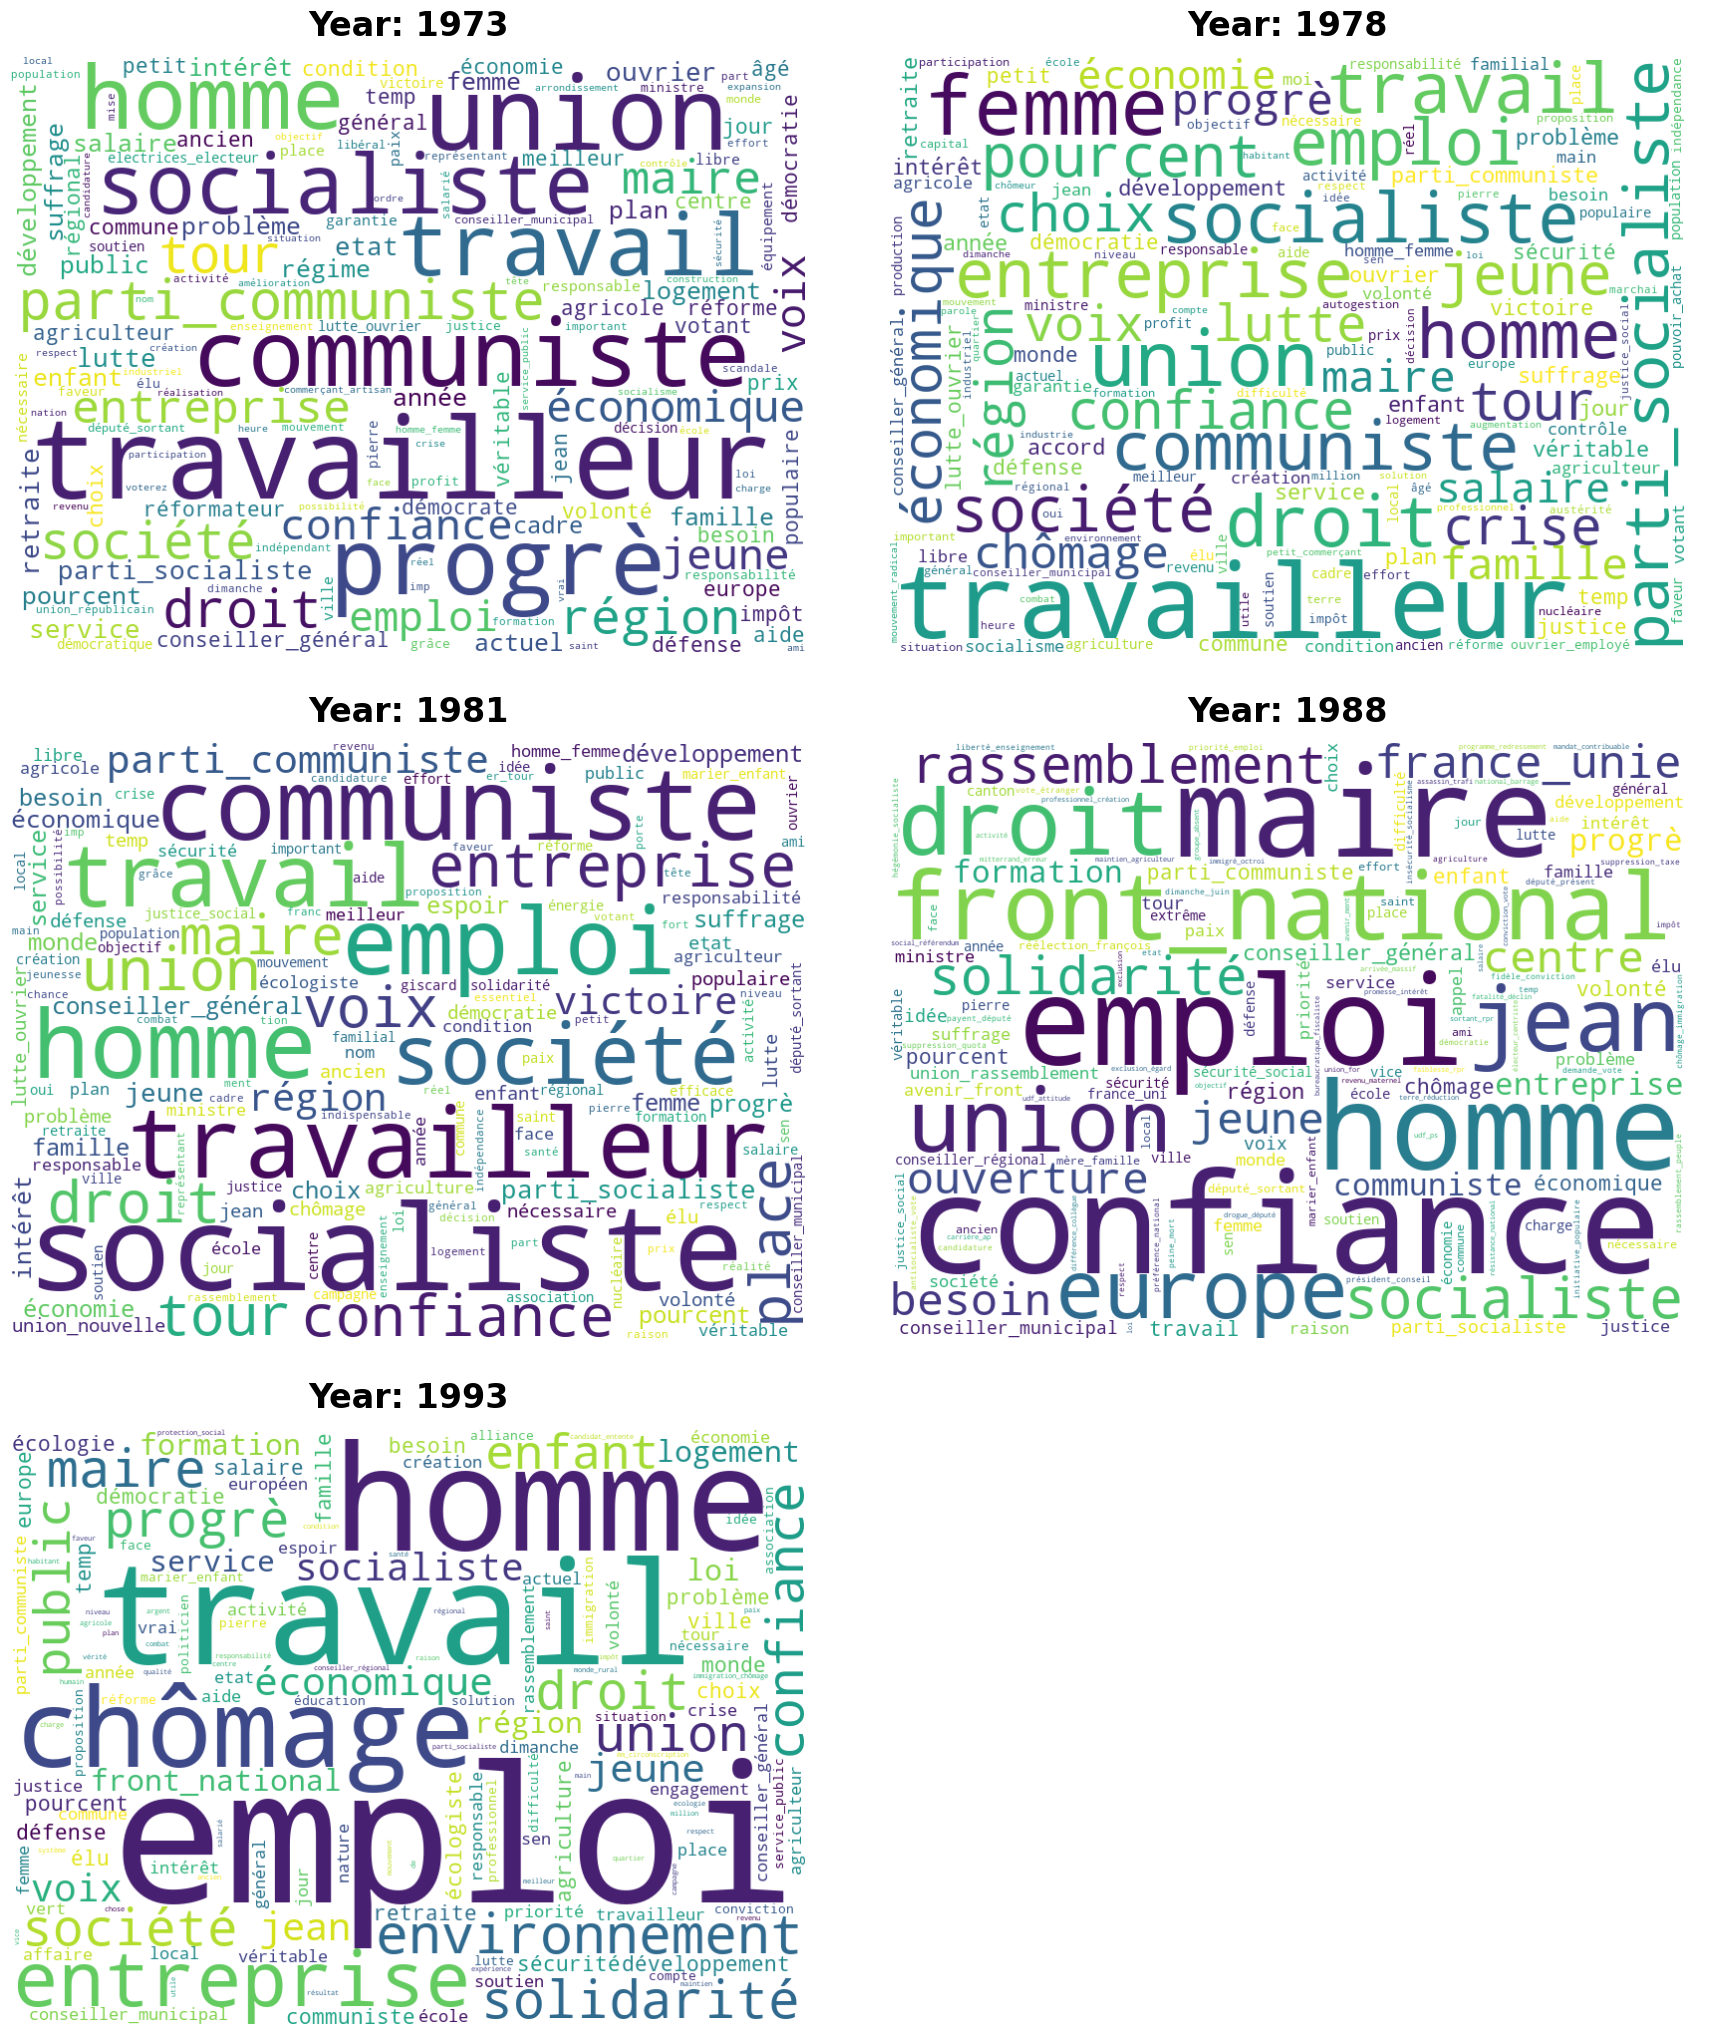

In [54]:
ncols = 2
nrows = math.ceil(num_years / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 7 * nrows))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    
    # Filter for the current year
    subset = filtered_df[filtered_df['year'] == year]
    text_data = " ".join(subset['final_tokens'].dropna().astype(str))
        
    # Generate the Word Cloud 
    wordcloud = WordCloud(
        width=800,
        height=600,
        background_color='white',    
        colormap='viridis',          
        max_words=150,               
        collocations=False,          
        random_state=42              
    ).generate(text_data)
    
    # Plot
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f"Year: {year}", fontsize=24, pad=15, fontweight='bold')
    ax.axis('off')

# Hide any leftover empty subplots 
for j in range(num_years, len(axes)):
    axes[j].axis('off')

# Adjust and display
plt.tight_layout(pad=3.0)
plt.show()


## Word Cloud by Gender

In [55]:
genders = sorted(filtered_df['titulaire-sexe'].dropna().unique())

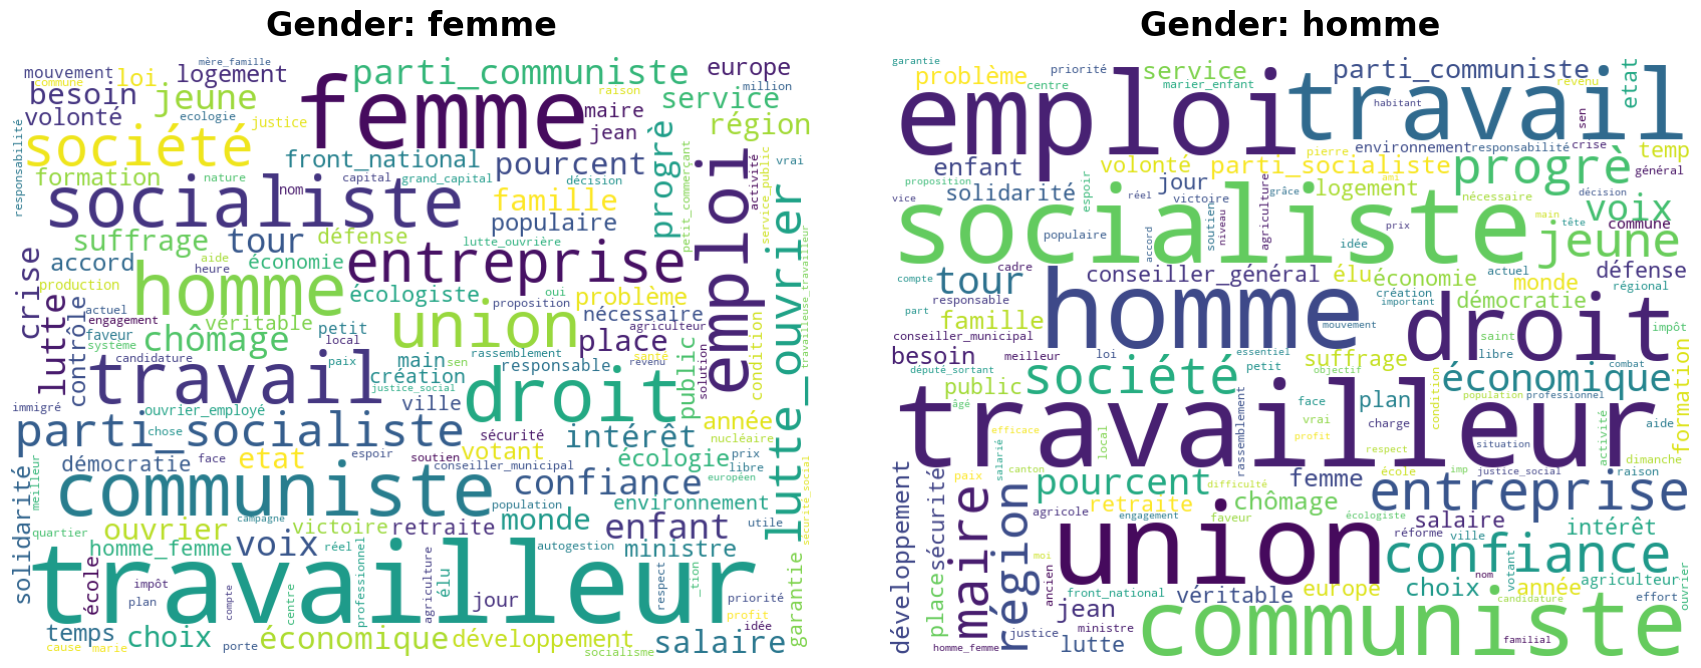

In [56]:
# Define grid 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))
axes = axes.flatten()

for i, genders in enumerate(genders):
    ax = axes[i]
    
    # Filter for the current year
    subset = filtered_df[filtered_df['titulaire-sexe'] == genders]
    text_data = " ".join(subset['final_tokens'].dropna().astype(str))
        
    # Generate the Word Cloud 
    wordcloud = WordCloud(
        width=800,
        height=600,
        background_color='white',    
        colormap='viridis',          
        max_words=150,               
        collocations=False,          
        random_state=42              
    ).generate(text_data)
    
    # Plot
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f"Gender: {genders}", fontsize=24, pad=15, fontweight='bold')
    ax.axis('off')

for j in range(num_genders, len(axes)):
    axes[j].axis('off')

# Adjust and display
plt.tight_layout(pad=3.0)
plt.show()
